In [40]:
import cv2

In [42]:
import numpy as np

In [44]:
import matplotlib.pyplot as plt

In [6]:
lena = cv2.imread(r"C:\Users\imyla\Downloads\Leana.jpg")

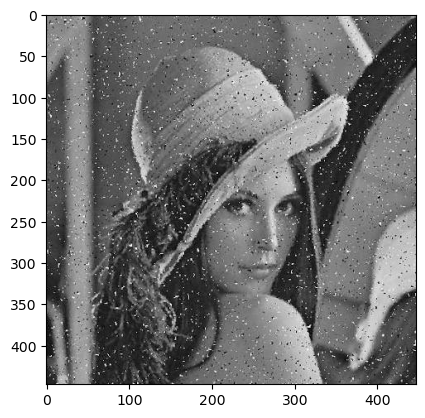

In [7]:
plt.imshow(lena)
plt.show()

In [28]:
average = cv2.blur(lena,(5,5))
median = cv2.medianBlur(lena,5)

In [30]:
cv2.imshow("average",average)
cv2.waitKey(0)
cv2.imshow("median",median)
cv2.waitKey(0)

-1

In [48]:
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    cv2.imshow("cam",frame)
    if cv2.waitKey(1) == ord("q"):
        break
cap.release()
cv2.destroyAllWindows()

AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

In [52]:
print(cv2.__version__)
print(cv2.__file__)

5.0.0
C:\Users\imyla\OneDrive\Attachments\Lib\site-packages\cv2\__init__.py


In [54]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))
print(hasattr(cv2, "data"))
print(cv2.getBuildInformation()[:500])

5.0.0
False
True

General configuration for OpenCV 5.0.0 =====================================
  Version control:               5.0.0

  Platform:
    Timestamp:                   2026-07-01T09:07:32Z
    Host:                        Windows 10.0.20348 AMD64
    CMake:                       4.3.2
    CMake generator:             Visual Studio 17 2022
    CMake build tool:            C:/Program Files/Microsoft Visual Studio/2022/Enterprise/MSBuild/Current/Bin/amd64/MSBuild.exe
    MSVC:                        194


In [58]:
print([x for x in dir(cv2) if "Cascade" in x])

[]


In [60]:
!pip list | findstr opencv

opencv-python                     5.0.0.93


In [62]:
pip uninstall opencv-python

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
!pip list | findstr numpy
!pip list | findstr opencv

numpy                             1.26.4
numpydoc                          1.7.0
opencv-python                     5.0.0.93


In [3]:
pip uninstall opencv-python

^C
Note: you may need to restart the kernel to use updated packages.


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(r"C:\Users\imyla\Downloads\gettyimages-2184183687-640_adpp.mp4")
FaceModel = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eyeModel = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
while True:
    ret, frame = cap.read()
    
    if not ret:
        break
        
    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    faces = FaceModel.detectMultiScale(gray)
    eyes = eyeModel.detectMultiScale(gray)

    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
        
    for (x,y,w,h) in eyes:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        
    cv2.imshow("cam",frame)
    
    if cv2.waitKey(1) == ord("q"):
        break
        
cap.release()
cv2.destroyAllWindows()

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [93]:
FaceModel = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eyeModel = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

In [95]:
def faceDetection(img):
    img_copy = img.copy()
    gray = cv2.cvtColor(img_copy,cv2.COLOR_BGR2GRAY)
    face = FaceModel.detectMultiScale(gray)
    for (x,y,w,h) in face:
        cv2.rectangle(img_copy,(x,y),(x+w,y+h),(0,0,255),2)
    return img_copy

In [97]:
def eyeDetection(img):
    img_copy2 = img.copy()
    gray = cv2.cvtColor(img_copy2,cv2.COLOR_BGR2GRAY)
    face = eyeModel.detectMultiScale(gray)
    for (x,y,w,h) in face:
        cv2.rectangle(img_copy2,(x,y),(x+w,y+h),(0,255,0),2)
    return img_copy2

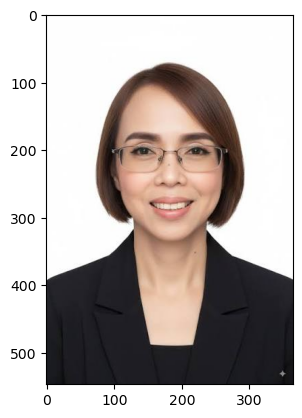

In [99]:
img = cv2.imread(r"C:\Users\imyla\Downloads\IDimages.jpg")
#imgFace = img.copy()
#imgEye = img.copy()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

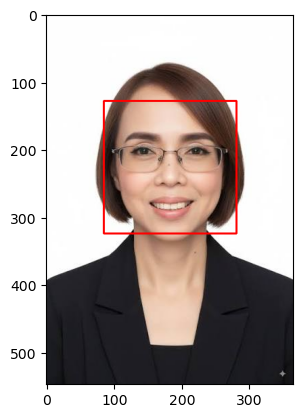

In [101]:
img_faceDetected = faceDetection(img)
plt.imshow(cv2.cvtColor(img_faceDetected, cv2.COLOR_BGR2RGB))

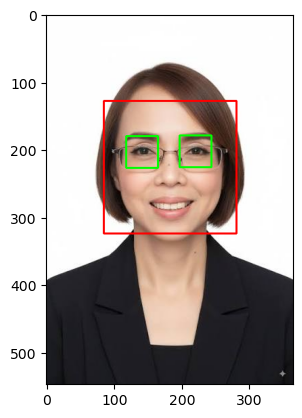

In [103]:
img_eyeDetected = eyeDetection(img_faceDetected)
plt.imshow(cv2.cvtColor(img_eyeDetected, cv2.COLOR_BGR2RGB))